# Creating an XGBoost Forecast model
[📥 Download Notebook](https://github.com/Mosqlimate-project/mosqlimate-client/blob/main/docs/tutorials/xgb_model.ipynb)
 
In this notebook we will show how to create an XGBoost forecast model using the `mosqlient` package.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("API_KEY")

In [3]:
import pandas as pd
from datetime import date
from mosqlient.datastore import Infodengue
from mosqlient.forecast import ForecastXGB
from mosqlient.forecast.viz import (
    plot_training_model_loss,
    plot_model_comparison,
    plot_single_forecast,
)

Before applying the XGBoost model, it is necessary to load the data. In this example, we will use the dengue data in Rio de Janeiro city (geocode = 3304557). The model uses `casos` as the target and can use the available climate and epidemiological variables as predictors.

In [4]:
disease = 'dengue'
geocode = 3304557 
end_date = date.today().strftime('%Y-%m-%d')

df = Infodengue.get(api_key = api_key,
                    disease =  disease,
                    start = "2010-01-01",
                    end = end_date, 
                    geocode = geocode)

df = pd.DataFrame(df)
df['data_iniSE'] = pd.to_datetime(df['data_iniSE'])

df = df[['data_iniSE', 'casos', 'tempmin', 'umidmin', 'Rt']]
df = df.set_index('data_iniSE')
df = df.resample('W-SUN').agg({
    'casos': 'sum',
    'tempmin': 'mean',
    'umidmin': 'mean',
    'Rt': 'mean',
})

df.head()

100%|██████████| 2/2 [00:03<00:00,  1.62s/requests]


,casos,tempmin,umidmin,Rt
data_iniSE,,,,
2010-01-03,30,25.142857,45.857143,0.0
2010-01-10,44,24.428571,40.857143,0.0
2010-01-17,46,23.857143,37.857143,0.0
2010-01-24,47,23.714286,42.857143,0.0
2010-01-31,68,25.142857,33.571429,0.0


The cell below creates the XGBoost forecast model. It uses previous observations as lag features, rolling statistics, calendar features and the supplied predictors. By default, it uses a residual formulation: it first calculates a baseline from the recent case history and then learns the correction needed to reach the future observed value. For a prediction at time `t`, this baseline uses only values available before `t`, so the current or future target is not used. This formulation helps the model follow the local level of the series and was the best-performing configuration in the benchmark. Set `residual=False` to use direct XGBoost predictions. The model predicts four weekly steps at a time.


The target and predictor columns are passed explicitly. The date column remains separate so that the model can create calendar features.

### Define the model hyperparameters

These parameters control the input window, forecasting horizon and the size and regularization of the boosted-tree ensemble.

| Parameter | Description |
| --- | --- |
| `look_back` | Number of previous weeks used to create lag features. |
| `predict_n` | Number of future weeks predicted by each training row. |
| `n_estimators` | Maximum number of boosting trees. |
| `max_depth` | Maximum depth of each tree; larger values can overfit. |
| `learning_rate` | Contribution of each new tree. |
| `early_stopping_rounds` | Stops training when validation error stops improving. |
| `val_ratio` | Fraction of the final training rows reserved for validation. |
| `residual` | Learns a correction over the recent-case rolling mean; enabled by default. |
| `use_log` | Applies `log1p` to the target during training and reverses it in predictions. |

`casos` is the target. The other selected columns are predictors. At each prediction origin, the model uses lagged values and calendar information; future predictor values are carried forward from the last observation by the recursive forecast implementation. In residual mode, the recent-case rolling mean provides the starting point and XGBoost predicts the difference from that point. The rolling mean is shifted by one week, which keeps the residual calculation causal and avoids using the value being predicted.

In [5]:
columns = ['casos', 'tempmin', 'umidmin', 'Rt']
target_col = 'casos'
look_back = 4
predict_n = 4
n_estimators = 500
max_depth = 3
learning_rate = 0.03
use_log = True
early_stopping_rounds = 40
val_ratio = 0.15

In [6]:
m_xgb = ForecastXGB(
    df_data=df.reset_index(),
    columns=columns,
    date_col='data_iniSE',
    target_col=target_col,
    look_back=look_back,
    predict_n=predict_n,
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
)

m_xgb

### Train the model 

To train the model, define the initial date, the last date used for training and the end of the available evaluation data. Rows whose future targets cross `end_train_date` are excluded from training, so the validation and test periods remain chronologically separated.

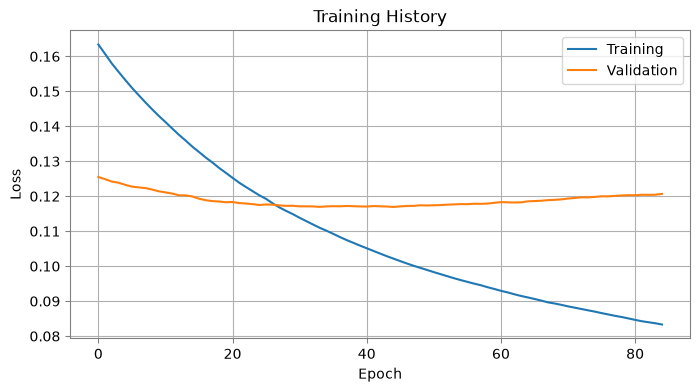

In [7]:
model, history = m_xgb.train(
    ini_train_date='2010-01-01',
    end_train_date='2021-12-31',
    end_date='2023-12-31',
    use_log=use_log,
    early_stopping_rounds=early_stopping_rounds,
    val_ratio=val_ratio,
)

_, ax = plot_training_model_loss(history)

#### Predictions in sample

Performance of the model on the training sample.

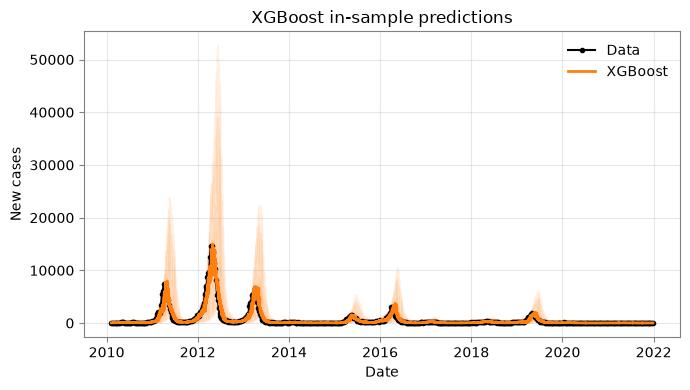

In [8]:
df_in_sample = m_xgb.predict_in_sample()

_, ax = plot_model_comparison(
    df_preds=df_in_sample,
    date_col='date',
    target_col='casos',
    label='XGBoost',
    title='XGBoost in-sample predictions',
    xlabel='Date',
    ylabel='New cases',
)

In [9]:
df_in_sample.head()

,last_date,date,horizon,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,casos
0,2010-01-31,2010-02-07,1,15.024739,17.416558,20.900789,34.550913,49.254081,56.386500,67.257694,81.496111,94.761709,56
1,2010-01-31,2010-02-14,2,10.111110,13.914902,18.242298,29.245250,46.405816,64.892712,81.944917,109.348340,126.598391,66
2,2010-01-31,2010-02-21,3,9.505200,10.506752,17.333612,28.926898,45.467141,76.512800,96.849211,133.355615,155.012817,74
3,2010-01-31,2010-02-28,4,8.917139,9.187348,15.828836,28.903051,49.444738,94.992011,115.590249,178.184921,208.625942,95
4,2010-02-07,2010-02-14,1,18.926537,21.494706,26.372150,42.423278,61.438763,67.254837,90.584101,103.764432,116.334983,66


#### Predictions out of sample

The out-of-sample performance starts after the last date used to train the model.

The returned dataframe contains the observed values and the predictions generated for the evaluation period.

,last_date,date,horizon,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,casos
0,2022-01-02,2022-01-09,1,1.683678,2.206968,2.829900,5.073457,7.286122,9.352539,13.308548,13.510755,15.044017,14
1,2022-01-02,2022-01-16,2,0.934626,1.569358,2.278875,4.289195,7.169598,10.014043,13.275110,16.259863,20.923822,22
2,2022-01-02,2022-01-23,3,0.674058,1.097486,2.119886,4.484213,7.872337,11.246298,16.165446,19.539525,24.659821,19
3,2022-01-02,2022-01-30,4,0.594885,0.839161,1.813078,4.596181,7.612598,13.079445,21.082153,29.517235,36.547675,31
4,2022-01-09,2022-01-16,1,1.915334,2.485124,3.731355,6.298171,8.987292,13.023200,16.663999,19.735149,21.307887,22


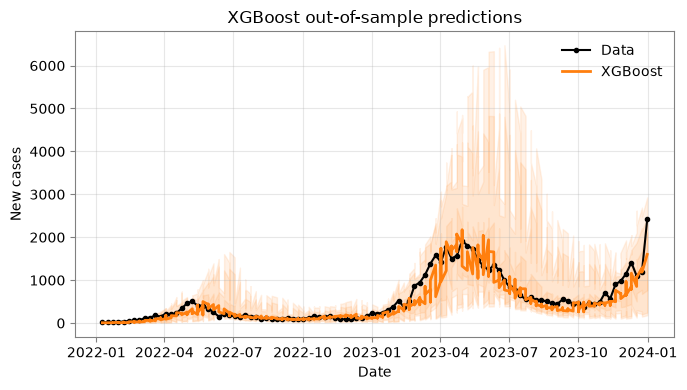

In [10]:
df_out = m_xgb.predict_out_of_sample()

_, ax = plot_model_comparison(
    df_preds=df_out,
    date_col='date',
    target_col='casos',
    label='XGBoost',
    title='XGBoost out-of-sample predictions',
    xlabel='Date',
    ylabel='New cases',
)

df_out.head()

### Forecast 

To forecast beyond the available observations, the model must be trained first. The forecast starts after the last observed date. 

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon
0,2026-08-02,2026-08-09,117.969153,117.969153,135.611717,153.434911,161.792702,190.190358,281.453913,336.305961,394.637884,1
1,2026-08-02,2026-08-16,108.550457,123.134474,124.659643,136.311863,144.349247,189.079762,249.339897,316.612297,405.314091,2
2,2026-08-02,2026-08-23,78.752006,100.421135,117.813130,118.200228,136.678359,187.346189,247.190600,306.141808,425.355805,3
3,2026-08-02,2026-08-30,84.930385,84.930385,100.901342,102.473831,132.754969,162.614807,252.765726,342.128617,506.294336,4


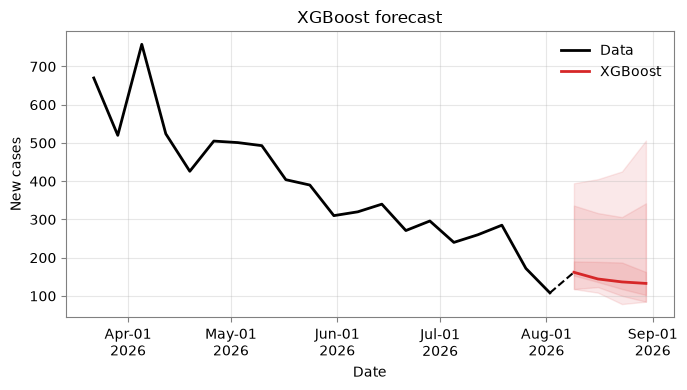

In [11]:
model, history = m_xgb.train(
    ini_train_date='2010-01-01',
    end_train_date=end_date,
    end_date=end_date,
)

forecast_end_date = (pd.Timestamp(end_date) + pd.Timedelta(weeks=8)).strftime('%Y-%m-%d')
df_for = m_xgb.forecast(end_date=forecast_end_date)

df_train = (
    m_xgb.df_model.reset_index()
    .rename(columns={'data_iniSE': 'date', 'casos': 'data'})
)
_, ax = plot_single_forecast(
    df_for=df_for,
    df_train=df_train,
    target_col='data',
    date_col='date',
    title='XGBoost forecast',
    label='XGBoost',
    xlabel='Date',
    ylabel='New cases',
)

df_for.head()